In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

file_path = r"C:\Users\Lukas\Downloads\Realisierter_Stromverbrauch_202605250000_202606010000_Viertelstunde.csv"

# Zuerst: nur laden und inspizieren
df = pd.read_csv(file_path, sep=";", encoding='utf-8-sig')

print("Spalten:")
print(df.columns.tolist())
print("\nErste Zeile:")
print(df.iloc[0])
print("\nDatentyp der Netzlast-Spalte:")
print(df['Netzlast [MWh] Originalauflösungen'].dtype)
print("\nEine Beispielwert:")
print(repr(df['Netzlast [MWh] Originalauflösungen'].iloc[0]))

Spalten:
['Datum von', 'Datum bis', 'Netzlast [MWh] Originalauflösungen', 'Netzlast inkl. Pumpspeicher [MWh] Originalauflösungen', 'Pumpspeicher [MWh] Originalauflösungen', 'Residuallast [MWh] Originalauflösungen']

Erste Zeile:
Datum von                                                25.05.2026 00:00
Datum bis                                                25.05.2026 00:15
Netzlast [MWh] Originalauflösungen                              10.108,08
Netzlast inkl. Pumpspeicher [MWh] Originalauflösungen           10.109,44
Pumpspeicher [MWh] Originalauflösungen                               1,36
Residuallast [MWh] Originalauflösungen                           8.232,90
Name: 0, dtype: str

Datentyp der Netzlast-Spalte:
str

Eine Beispielwert:
'10.108,08'


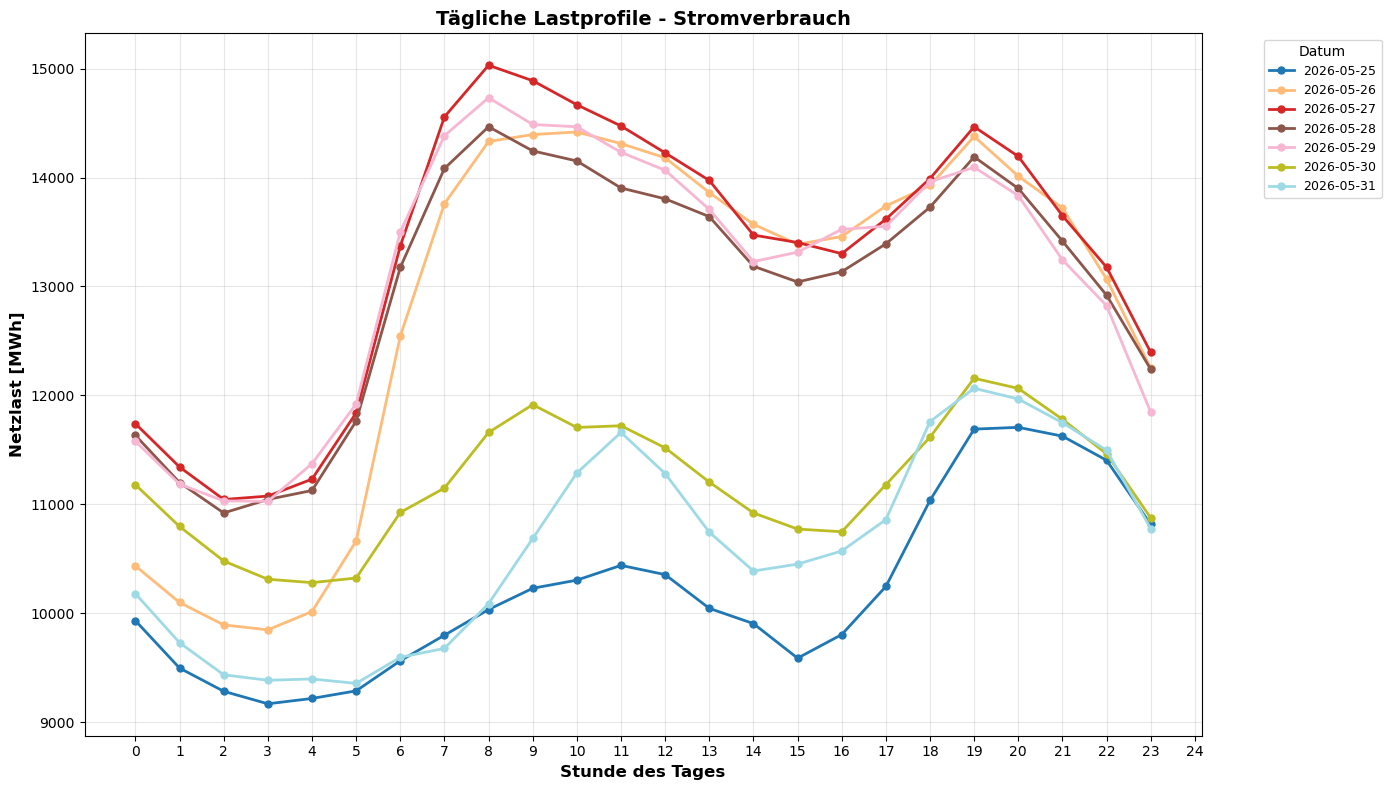

Daten von 2026-05-25 bis 2026-05-31 (7 Tage)
Durchschnittliche Last: 12042.48 MWh


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

file_path = r"C:\Users\Lukas\Downloads\Realisierter_Stromverbrauch_202605250000_202606010000_Viertelstunde.csv"

# CSV laden
df = pd.read_csv(file_path, sep=";", encoding='utf-8-sig')

# Spalte konvertieren: Erst Punkt (Tausendertrennzeichen) entfernen, dann Komma durch Punkt ersetzen
df['Netzlast [MWh] Originalauflösungen'] = pd.to_numeric(
    df['Netzlast [MWh] Originalauflösungen']
    .str.replace('.', '', regex=False)  # Alle Punkte entfernen
    .str.replace(',', '.', regex=False),  # Komma durch Punkt ersetzen
    errors='coerce'
)

# NaN-Werte entfernen
df = df.dropna(subset=['Netzlast [MWh] Originalauflösungen'])

# Datum-Spalte in datetime konvertieren
df['Datum_von'] = pd.to_datetime(df['Datum von'], format='%d.%m.%Y %H:%M')

# Stunde und Tag extrahieren
df['Stunde'] = df['Datum_von'].dt.hour
df['Tag'] = df['Datum_von'].dt.date

# Nach Tag und Stunde aggregieren (Durchschnitt der Viertelstundenwerte)
aggregated = df.groupby(['Tag', 'Stunde'])['Netzlast [MWh] Originalauflösungen'].mean().reset_index()

# Plot erstellen
fig, ax = plt.subplots(figsize=(14, 8))

# Eindeutige Tage bekommen
unique_days = sorted(aggregated['Tag'].unique())

# Farbpalette erstellen
colors = plt.cm.tab20(np.linspace(0, 1, len(unique_days)))

# Für jeden Tag eine Linie zeichnen
for idx, day in enumerate(unique_days):
    day_data = aggregated[aggregated['Tag'] == day].sort_values('Stunde')
    ax.plot(day_data['Stunde'], day_data['Netzlast [MWh] Originalauflösungen'], 
            marker='o', label=str(day), color=colors[idx], linewidth=2, markersize=5)

# Achsen und Labels formatieren
ax.set_xlabel('Stunde des Tages', fontsize=12, fontweight='bold')
ax.set_ylabel('Netzlast [MWh]', fontsize=12, fontweight='bold')
ax.set_title('Tägliche Lastprofile - Stromverbrauch', fontsize=14, fontweight='bold')
ax.set_xticks(range(0, 25))
ax.grid(True, alpha=0.3)
ax.legend(title='Datum', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

print(f"Daten von {unique_days[0]} bis {unique_days[-1]} ({len(unique_days)} Tage)")
print(f"Durchschnittliche Last: {aggregated['Netzlast [MWh] Originalauflösungen'].mean():.2f} MWh")